<a href="https://colab.research.google.com/github/toryor31oct/group15-Fun-Rai-Kwam-plod-Phai/blob/main/final_fun_rai_kwam_plod_phai_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [289]:
import random
import sqlite3
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

In [290]:
# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-thai-tlwg is already the newest version (1:0.7.3-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


# Customer

In [291]:
import random
import pandas as pd
import sqlite3

# ============================================================
# 1. Class Customer
# ============================================================

class Customer:

    def __init__(
        self,
        customer_id,
        name,
        phone,
        age,
        occupation,
        gender,
        house_no,
        moo,
        subdistrict,
        district,
        province,
        postal_code,
        marital_status,
        beneficiary_name,
        beneficiary_relationship,
        annual_income
    ):

        self.customer_id = customer_id
        self.name = name
        self.phone = phone
        self.age = age
        self.occupation = occupation
        self.gender = gender

        self.house_no = house_no
        self.moo = moo
        self.subdistrict = subdistrict
        self.district = district
        self.province = province
        self.postal_code = postal_code

        self.marital_status = marital_status
        self.beneficiary_name = beneficiary_name
        self.beneficiary_relationship = beneficiary_relationship
        self.annual_income = annual_income


In [292]:
# ============================================================
# 2. รายชื่อ
# ============================================================

first_names = [
    "สมชาย", "สมหญิง", "ณัฐวุฒิ", "กิตติพงษ์",
    "พิมพ์ชนก", "ธนภัทร", "อรทัย", "ศิริพร",
    "วรพล", "นภัสสร", "ภัทรพล", "ชลธิชา",
    "ปวีณา", "ธีรภัทร์", "สุภาวดี", "อนันต์",
    "กัญญารัตน์", "ภูมิพัฒน์", "อรปรียา", "ศุภชัย",
    "ธนกร", "ณิชาภัทร", "พัชราภา", "เอกภพ",
    "มณีรัตน์", "ชยพล", "รัตนาภรณ์", "วรัญญา"
]

last_names = [
    "ใจดี", "แสงทอง", "ศรีสุข", "วัฒนชัย",
    "รุ่งเรือง", "สุขสวัสดิ์", "บุญมี", "แก้วใส",
    "อินทร์ทอง", "พรหมดี", "คงมั่น", "มีสุข",
    "สายทอง", "อินทร์ดี", "เจริญสุข", "พงษ์ดี",
    "วงศ์ดี", "บุญช่วย", "ทองดี", "ศรีทอง",
    "แก้วมณี", "สุวรรณ", "คงดี", "ทองคำ"
]


In [293]:
# ============================================================
# 3. อาชีพ
# ============================================================

occupations = [
    "พนักงานบริษัท",
    "ครู",
    "แพทย์",
    "พยาบาล",
    "วิศวกร",
    "นักบัญชี",
    "โปรแกรมเมอร์",
    "พนักงานขาย",
    "คนขับรถ",
    "ช่างก่อสร้าง",
    "เกษตรกร",
    "ตำรวจ"
]

In [294]:
# ============================================================
# 4. จังหวัดและที่อยู่
# ============================================================

locations = [

    {
        "subdistrict": "ในเมือง",
        "district": "เมืองขอนแก่น",
        "province": "ขอนแก่น",
        "postal_code": "40000"
    },

    {
        "subdistrict": "ศิลา",
        "district": "เมืองขอนแก่น",
        "province": "ขอนแก่น",
        "postal_code": "40000"
    },

    {
        "subdistrict": "บ้านเป็ด",
        "district": "เมืองขอนแก่น",
        "province": "ขอนแก่น",
        "postal_code": "40000"
    },

    {
        "subdistrict": "เมืองเก่า",
        "district": "เมืองขอนแก่น",
        "province": "ขอนแก่น",
        "postal_code": "40000"
    },

    {
        "subdistrict": "สำราญ",
        "district": "เมืองขอนแก่น",
        "province": "ขอนแก่น",
        "postal_code": "40000"
    },

    {
        "subdistrict": "กุดเค้า",
        "district": "มัญจาคีรี",
        "province": "ขอนแก่น",
        "postal_code": "40160"
    },

    {
        "subdistrict": "บ้านไผ่",
        "district": "บ้านไผ่",
        "province": "ขอนแก่น",
        "postal_code": "40110"
    },

    {
        "subdistrict": "ชุมแพ",
        "district": "ชุมแพ",
        "province": "ขอนแก่น",
        "postal_code": "40130"
    },

    {
        "subdistrict": "เมืองพล",
        "district": "พล",
        "province": "ขอนแก่น",
        "postal_code": "40120"
    },

    {
        "subdistrict": "น้ำพอง",
        "district": "น้ำพอง",
        "province": "ขอนแก่น",
        "postal_code": "40140"
    }
]

In [295]:
# ============================================================
# 5. สถานภาพ
# ============================================================

marital_statuses = [
    "โสด",
    "สมรส",
    "หย่าร้าง",
    "หม้าย"
]

In [296]:
# ============================================================
# 6. ความสัมพันธ์ของผู้รับผลประโยชน์
# ============================================================

beneficiary_relationships = [
    "บิดา",
    "มารดา",
    "สามี",
    "ภรรยา",
    "บุตร",
    "พี่น้อง"
]


In [297]:
# ============================================================
# 7. สร้างเบอร์โทรศัพท์
# ============================================================

def generate_phone():
    prefix = random.choice([
        "081",
        "082",
        "083",
        "084",
        "085",
        "086",
        "087",
        "088",
        "089"
    ])

    number = random.randint(
        1000000,
        9999999
    )
    return prefix + str(number)

In [298]:
# ============================================================
# 8. สร้างรายได้ตามอาชีพ
# ============================================================

def generate_income(occupation):

    income_range = {
        "พนักงานบริษัท": (180000, 600000),
        "ครู": (240000, 600000),
        "แพทย์": (600000, 1800000),
        "พยาบาล": (240000, 600000),
        "วิศวกร": (300000, 900000),
        "นักบัญชี": (240000, 600000),
        "โปรแกรมเมอร์": (300000, 1200000),
        "พนักงานขาย": (180000, 600000),
        "คนขับรถ": (180000, 480000),
        "ช่างก่อสร้าง": (180000, 600000),
        "เกษตรกร": (120000, 500000),
        "ตำรวจ": (240000, 600000)
    }
    minimum, maximum = income_range[occupation]

    # ให้รายได้เป็นหลักพัน
    return random.randint(
        minimum // 1000,
        maximum // 1000
    ) * 1000


In [299]:
# ============================================================
# 9. สร้างชื่อผู้รับผลประโยชน์
# ============================================================

def generate_beneficiary_name(customer_name):

    beneficiary_name = (
        random.choice(first_names)
        + " "
        + random.choice(last_names)
    )

    # ป้องกันไม่ให้ชื่อผู้รับผลประโยชน์เหมือนลูกค้า
    while beneficiary_name == customer_name:

        beneficiary_name = (

            random.choice(first_names)
            + " "
            + random.choice(last_names)
        )

    return beneficiary_name

In [300]:
# ============================================================
# 10. สร้างข้อมูล Customer 300 คน
# ============================================================

customer_data = []
for i in range(300):

    # --------------------------------------------------------
    # ชื่อ
    # --------------------------------------------------------

    name = (
        random.choice(first_names)
        + " "
        + random.choice(last_names)
    )

    # --------------------------------------------------------
    # อายุ
    # --------------------------------------------------------

    age = random.randint(20,65)

    # --------------------------------------------------------
    # อาชีพ
    # --------------------------------------------------------

    occupation = random.choice(occupations)

    # --------------------------------------------------------
    # เพศ
    # --------------------------------------------------------

    gender = random.choice(["ชาย", "หญิง"])

    # --------------------------------------------------------
    # ที่อยู่
    # --------------------------------------------------------

    location = random.choice(locations)

    house_no = (
        str(random.randint(1, 299))
        + "/"
        + str(random.randint(1, 99))
    )

    moo = random.randint(1,15)

    # --------------------------------------------------------
    # สถานภาพ
    # --------------------------------------------------------

    if age < 25:
        marital_status = random.choice([
            "โสด",
            "โสด",
            "โสด",
            "สมรส"
        ])

    else:
        marital_status = random.choice(marital_statuses)

    # --------------------------------------------------------
    # ผู้รับผลประโยชน์
    # --------------------------------------------------------

    beneficiary_name = generate_beneficiary_name(name)
    beneficiary_relationship = random.choice(beneficiary_relationships)

    # --------------------------------------------------------
    # อาชีพ → รายได้
    # --------------------------------------------------------

    annual_income = generate_income(occupation)

    # --------------------------------------------------------
    # สร้าง Customer
    # --------------------------------------------------------

    customer = Customer(
        f"C{i+1:03d}",
        name,
        generate_phone(),
        age,
        occupation,
        gender,
        house_no,
        moo,
        location["subdistrict"],
        location["district"],
        location["province"],
        location["postal_code"],
        marital_status,
        beneficiary_name,
        beneficiary_relationship,
        annual_income
    )

    # --------------------------------------------------------
    # เก็บข้อมูล
    # --------------------------------------------------------

    customer_data.append([

        customer.customer_id,
        customer.name,
        customer.phone,
        customer.age,
        customer.occupation,
        customer.gender,

        customer.house_no,
        customer.moo,
        customer.subdistrict,
        customer.district,
        customer.province,
        customer.postal_code,

        customer.marital_status,
        customer.beneficiary_name,
        customer.beneficiary_relationship,

        customer.annual_income
    ])


In [301]:
# ============================================================
# 11. สร้าง DataFrame
# ============================================================

columns = [

    "Customer_ID",
    "Customer_Name",
    "Phone",
    "Age",
    "Occupation",
    "Gender",

    "House_No",
    "Moo",
    "Subdistrict",
    "District",
    "Province",
    "Postal_Code",

    "Marital_Status",
    "Beneficiary_Name",
    "Beneficiary_Relationship",

    "Annual_Income"
]

df_customer = pd.DataFrame(customer_data, columns=columns)

In [302]:
# ============================================================
# 12. บันทึก CSV
# ============================================================

df_customer.to_csv("customer.csv",index=False,encoding="utf-8-sig")

# ============================================================
# 13. บันทึก SQLite
# ============================================================

conn = sqlite3.connect("insurance.db")
df_customer.to_sql("customer", conn, if_exists="replace", index=False)
conn.close()


In [303]:
# ============================================================
# 14. ตรวจสอบข้อมูล
# ============================================================

print("จำนวนแถวและคอลัมน์:",df_customer.shape)
display(df_customer.head(300))

จำนวนแถวและคอลัมน์: (300, 16)


,Customer_ID,Customer_Name,Phone,Age,Occupation,Gender,House_No,Moo,Subdistrict,District,Province,Postal_Code,Marital_Status,Beneficiary_Name,Beneficiary_Relationship,Annual_Income
0,C001,ปวีณา คงมั่น,0891873851,33,พนักงานขาย,หญิง,195/36,13,กุดเค้า,มัญจาคีรี,ขอนแก่น,40160,หม้าย,วรพล ศรีสุข,ภรรยา,189000
1,C002,ชลธิชา แก้วใส,0882919136,61,ครู,ชาย,127/26,14,ในเมือง,เมืองขอนแก่น,ขอนแก่น,40000,โสด,ศุภชัย รุ่งเรือง,มารดา,304000
2,C003,อรปรียา บุญมี,0816233774,49,ตำรวจ,หญิง,86/78,10,กุดเค้า,มัญจาคีรี,ขอนแก่น,40160,โสด,มณีรัตน์ สุขสวัสดิ์,สามี,295000
3,C004,อรปรียา สุวรรณ,0821689025,44,โปรแกรมเมอร์,ชาย,125/14,12,ศิลา,เมืองขอนแก่น,ขอนแก่น,40000,หย่าร้าง,วรัญญา สุวรรณ,บุตร,1124000
4,C005,ชลธิชา บุญช่วย,0877076506,47,เกษตรกร,หญิง,260/83,6,ศิลา,เมืองขอนแก่น,ขอนแก่น,40000,โสด,วรัญญา อินทร์ดี,ภรรยา,174000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,C296,ภูมิพัฒน์ บุญช่วย,0832997927,50,แพทย์,หญิง,285/62,5,เมืองพล,พล,ขอนแก่น,40120,หย่าร้าง,อรปรียา มีสุข,พี่น้อง,1415000
296,C297,เอกภพ แก้วใส,0813696736,48,ตำรวจ,ชาย,110/66,7,ศิลา,เมืองขอนแก่น,ขอนแก่น,40000,หย่าร้าง,ชยพล บุญช่วย,บุตร,596000
297,C298,ปวีณา แก้วมณี,0817447920,20,ครู,ชาย,223/12,2,ชุมแพ,ชุมแพ,ขอนแก่น,40130,โสด,ศิริพร มีสุข,บิดา,551000
298,C299,ปวีณา ศรีทอง,0854267304,61,คนขับรถ,หญิง,30/23,11,น้ำพอง,น้ำพอง,ขอนแก่น,40140,หม้าย,สุภาวดี ใจดี,มารดา,445000


# policy

In [304]:
import random
from datetime import datetime, timedelta
import pandas as pd

# โหลดข้อมูลลูกค้าจาก CSV
df_customers = pd.read_csv("customer.csv")


class Policy:
    """Class สำหรับจัดการกรมธรรม์ประกันภัย (แก้ไขเรื่อง Leap Year และ Edge Cases)"""

    PLAN_CONFIGS = {
        "ประกันชีวิต": {
            "base_rate": 0.015,
            "min_coverage": 500000,
            "max_coverage": 3000000,
            "payment_modes": ["รายปี", "รายเดือน"],
        },
        "ประกันสุขภาพ": {
            "base_rate": 0.025,
            "min_coverage": 200000,
            "max_coverage": 1500000,
            "payment_modes": ["รายปี", "รายกึ่งปี", "รายเดือน"],
        },
        "ประกันอุบัติเหตุ": {
            "base_rate": 0.005,
            "min_coverage": 100000,
            "max_coverage": 1000000,
            "payment_modes": ["รายปี"],
        },
        "ประกันโรคร้ายแรง": {
            "base_rate": 0.020,
            "min_coverage": 300000,
            "max_coverage": 2000000,
            "payment_modes": ["รายปี", "รายกึ่งปี"],
        },
    }

    RISK_OCCUPATIONS = {
        "ตำรวจ": 1.35,
        "คนขับรถ": 1.30,
        "เกษตรกร": 1.20,
        "วิศวกร": 1.15,
        "ค้าขาย": 1.05,
        "พนักงานบริษัท": 1.00,
        "แพทย์": 1.00,
        "ข้าราชการ": 0.95,
        "ครู": 0.95,
    }

    def __init__(
        self,
        policy_id,
        customer_id,
        plan_name,
        coverage_amount,
        payment_mode,
        age=30,
        occupation="พนักงานบริษัท",
        start_date=None,
    ):
        self.policy_id = policy_id
        self.customer_id = customer_id
        self.plan_name = plan_name
        self.coverage_amount = coverage_amount
        self.payment_mode = payment_mode
        self.age = age if pd.notnull(age) else 30  # ป้องกันค่า NaN
        self.occupation = (
            occupation if pd.notnull(occupation) else "พนักงานบริษัท"
        )

        # สุ่มวันที่เริ่มต้น
        self.start_date = (
            start_date
            if start_date
            else datetime(2025, 1, 1) + timedelta(days=random.randint(0, 360))
        )
        # ใช้ timedelta(days=365) ป้องกัน Error กรณีตรงกับวันที่ 29 ก.พ.
        self.end_date = self.start_date + timedelta(days=365)
        self.status = "Active"

        self.premium = self.calculate_premium()

    def calculate_premium(self):
        """คำนวณเบี้ยประกันตามปัจจัยความเสี่ยง"""
        base_rate = self.PLAN_CONFIGS[self.plan_name]["base_rate"]

        # ปัจจัยด้านอายุ
        if self.age < 30:
            age_factor = 0.90
        elif self.age <= 50:
            age_factor = 1.10
        else:
            age_factor = 1.35

        # ปัจจัยด้านอาชีพ
        occ_factor = self.RISK_OCCUPATIONS.get(self.occupation, 1.00)

        # เบี้ยประกันฐานต่อปี
        annual_premium = (
            self.coverage_amount * base_rate * age_factor * occ_factor
        )

        # งวดการชำระเงิน
        if self.payment_mode == "รายเดือน":
            premium = (annual_premium / 12) * 1.05
        elif self.payment_mode == "รายกึ่งปี":
            premium = (annual_premium / 2) * 1.02
        else:
            premium = annual_premium

        return round(premium, 2)


# --- จำลองสร้างข้อมูล 300 รายการ ---
random.seed(42)  # ตั้งค่า seed เพื่อให้ได้ผลลัพธ์สุ่มที่ซ้ำเดิมได้ตอนตรวจงาน
policies_list = []

for idx, row in df_customers.iterrows():
    policy_id = f"POL{idx+1:04d}"
    plan_name = random.choice(list(Policy.PLAN_CONFIGS.keys()))
    config = Policy.PLAN_CONFIGS[plan_name]

    coverage = (
        random.randint(
            config["min_coverage"] // 50000, config["max_coverage"] // 50000
        )
        * 50000
    )
    payment_mode = random.choice(config["payment_modes"])

    policy_obj = Policy(
        policy_id=policy_id,
        customer_id=row["Customer_ID"],
        plan_name=plan_name,
        coverage_amount=coverage,
        payment_mode=payment_mode,
        age=row["Age"],
        occupation=row["Occupation"],
    )

    policies_list.append(
        {
            "Policy_ID": policy_obj.policy_id,
            "Customer_ID": policy_obj.customer_id,
            "Plan_Name": policy_obj.plan_name,
            "Coverage_Amount": policy_obj.coverage_amount,
            "Payment_Mode": policy_obj.payment_mode,
            "Premium": policy_obj.premium,
            "Start_Date": policy_obj.start_date.strftime("%Y-%m-%d"),
            "End_Date": policy_obj.end_date.strftime("%Y-%m-%d"),
            "Status": policy_obj.status,
        }
    )

df_policies = pd.DataFrame(policies_list)
df_policies.to_csv("policy.csv", index=False, encoding="utf-8-sig")

print("ตรวจสอบและรันข้อมูลเรียบร้อยแล้ว ได้ไฟล์ policy.csv จำนวน 300 รายการ")

ตรวจสอบและรันข้อมูลเรียบร้อยแล้ว ได้ไฟล์ policy.csv จำนวน 300 รายการ


# claim system

In [305]:
import random
import sqlite3
import pandas as pd

df_customer = pd.read_csv("customer.csv")
df_policy = pd.read_csv("policy.csv")

# รวมข้อมูลลูกค้าและกรมธรรม์เพื่อเตรียมใช้จำลองการเคลม
df_base_policies = pd.merge(
    df_policy,
    df_customer[[
        "Customer_ID",
        "Customer_Name",
        "Beneficiary_Name",
        "Beneficiary_Relationship",
    ]],
    on="Customer_ID",
    how="inner",
)

Class จากการวิเคราะห์องค์กร 3 Classes

In [306]:
# Class 1: เก็บข้อมูลคำร้องขอเคลมประกันภัยแต่ละรายการ
class ClaimRequest:
  def __init__(
      self, claim_id, policy_id, customer_id, insurance_type, claim_amount
  ):
    self.claim_id = claim_id
    self.policy_id = policy_id
    self.customer_id = customer_id
    self.insurance_type = insurance_type  # ประกันชีวิต, ประกันสุขภาพ, ประกันอุบัติเหตุ, ประกันโรคร้ายแรง
    self.claim_amount = claim_amount
    self.status = "Pending"  # ทุกคำร้องเริ่มที่สถานะ Pending

# Class 2: ประเมินอนุมัติเคลมตามกฎเงื่อนไขของประเภทประกัน
class ClaimAssessment:
  def __init__(self, assessment_id, claim_id):
    self.assessment_id = assessment_id
    self.claim_id = claim_id
    self.approval_status = "Pending"
    self.assessment_note = ""

  def process_approval(self, claim_amount, coverage_limit, insurance_type):
    """Method ตัดสินใจอนุมัติเคลมตามกฎซับซ้อนของแต่ละประเภทประกัน"""
    if insurance_type == "ประกันชีวิต":
      # ประกันชีวิต: อนุมัติจ่ายเต็มวงเงินคุ้มครอง (ทุนประกัน) กรณีมรณกรรมแก่ผู้รับประโยชน์
      self.approval_status = "Approved"
      self.assessment_note = (
          "อนุมัติจ่ายตามทุนประกันชีวิตเต็มจำนวนกรณีมรณกรรมแก่ผู้รับประโยชน์"
      )

    elif insurance_type == "ประกันโรคร้ายแรง":
      # ประกันโรคร้ายแรง: อนุมัติจ่ายเงินก้อน (Lump Sum) เมื่อตรวจพบโรคร้ายแรงตามเงื่อนไข
      self.approval_status = "Approved"
      self.assessment_note = (
          "อนุมัติจ่ายเงินก้อน (Lump Sum) เมื่อตรวจพบโรคร้ายแรงระยะที่คุ้มครอง"
      )

    elif insurance_type in ["ประกันสุขภาพ", "ประกันอุบัติเหตุ"]:
      # ประกันสุขภาพ / อุบัติเหตุ: อนุมัติตามค่ารักษาจริง แต่ต้องไม่เกินวงเงินคุ้มครอง
      if claim_amount <= coverage_limit:
        self.approval_status = "Approved"
        self.assessment_note = (
            "อนุมัติตามค่ารักษาพยาบาลจริง (อยู่ในวงเงินคุ้มครอง)"
        )
      else:
        self.approval_status = "Rejected"
        self.assessment_note = (
            f"ปฏิเสธ: ยอดขอเบิก ({claim_amount:,.2f} บาท) เกินวงเงินคุ้มครอง"
            f" ({coverage_limit:,.2f} บาท)"
        )

    return self.approval_status

# Class 3: จัดการคำนวณและสั่งจ่ายค่าสินไหมทดแทน
class ClaimPayment:
  def __init__(self, payment_id, claim_id):
    self.payment_id = payment_id
    self.claim_id = claim_id
    self.paid_amount = 0.0
    self.payment_status = "Unpaid"

  def process_payment(
      self, claim_amount, coverage_limit, insurance_type, approval_status
  ):
    """Method คำนวณยอดเงินจ่ายจริงตามผลการประเมิน"""
    if approval_status == "Approved":
      if insurance_type in ["ประกันชีวิต", "ประกันโรคร้ายแรง"]:
        # ประกันชีวิต และ โรคร้ายแรง จ่ายเต็มทุนประกันภัย
        self.paid_amount = coverage_limit
      else:
        # ประกันสุขภาพ และ อุบัติเหตุ จ่ายตามยอดขอเบิกจริง
        self.paid_amount = claim_amount
      self.payment_status = "Paid"
    else:
      self.paid_amount = 0.0
      self.payment_status = "Cancelled"
    return self.payment_status

Helper Functions

In [307]:
def generate_claim_details(insurance_type):
  """ฟังก์ชันที่ 1: สุ่มรายละเอียดสาเหตุการยื่นเคลมจำแนกตามประเภทประกัน"""
  details_map = {
      "ประกันชีวิต": [
          "เสียชีวิตจากโรคเจ็บป่วยรุนแรง",
          "เสียชีวิตจากอุบัติเหตุทางถนน",
          "เสียชีวิตจากภาวะหัวใจล้มเหลว",
      ],
      "ประกันสุขภาพ": [
          "เข้ารับการรักษาผู้ป่วยใน (IPD) โรคไข้หวัดใหญ่",
          "ผ่าตัดไส้ติ่งอักเสบฉุกเฉิน",
          "เข้ารับการรักษาผู้ป่วยนอก (OPD) ลำไส้อักเสบ",
      ],
      "ประกันอุบัติเหตุ": [
          "เข้ารักษาฉุกเฉินจากลื่นล้มหกล้ม",
          "กระดูกข้อเท้าแตกหักจากการเล่นกีฬา",
          "แผลฉกรรจ์จากอุบัติเหตุในบ้านเรือน",
      ],
      "ประกันโรคร้ายแรง": [
          "ตรวจพบโรคมะเร็งระยะเริ่มต้น/ระยะรุนแรง",
          "ตรวจพบโรคหลอดเลือดสมองแตกหรือตีบ",
          "ป่วยด้วยโรคกล้ามเนื้อหัวใจตายจากการขาดเลือด",
      ],
  }
  options = details_map.get(insurance_type, ["การเคลมค่าสินไหมทั่วไป"])
  return random.choice(options)


def generate_claim_amount(coverage_limit):
  """ฟังก์ชันที่ 2: สุ่มยอดเงินขอเบิกค่ารักษา/สินไหม"""
  return round(random.uniform(10000.0, coverage_limit * 1.15), 2)


def calculate_net_payout(paid_amount, tax_rate=0.01):
  """ฟังก์ชันที่ 3: คำนวณเงินสุทธิหลังหักภาษี ณ ที่จ่าย (มี default argument: tax_rate=0.01)"""
  return round(paid_amount * (1 - tax_rate), 2)


จำลองข้อมูลทีละรายการด้วย Loop (300 รายการ)

In [308]:
random.seed(42)  # ล็อค seed สำหรับ debug
requests_list = []
assessments_list = []
payments_list = []

for i in range(len(df_base_policies)):
  policy_row = df_base_policies.iloc[i]

  c_id = policy_row["Customer_ID"]
  p_id = policy_row["Policy_ID"]
  ins_type = policy_row["Plan_Name"]
  coverage = float(policy_row["Coverage_Amount"])

  clm_id = f"CLM{i+1:03d}"
  clm_amount = generate_claim_amount(coverage)

  # 1. สร้าง Object คำร้องยื่นเคลม
  req = ClaimRequest(clm_id, p_id, c_id, ins_type, clm_amount)
  claim_detail = generate_claim_details(ins_type)

  # 2. สร้าง Object ประเมินอนุมัติ
  ass_id = f"ASS{i+1:03d}"
  ass = ClaimAssessment(ass_id, req.claim_id)
  app_status = ass.process_approval(req.claim_amount, coverage, ins_type)
  req.status = app_status

  # 3. สร้าง Object สั่งจ่ายเงินสินไหม
  pay_id = f"PAY{i+1:03d}"
  pay = ClaimPayment(pay_id, req.claim_id)
  pay_status = pay.process_payment(
      req.claim_amount, coverage, ins_type, ass.approval_status
  )

  # เก็บ Object และข้อมูลที่เกี่ยวข้อง
  requests_list.append((req, policy_row, claim_detail))
  assessments_list.append(ass)
  payments_list.append(pay)

print(
    f"จำลองการรับและประมวลผลเคลมสำเร็จแล้วทั้งหมด {len(requests_list)} รายการ"
)


จำลองการรับและประมวลผลเคลมสำเร็จแล้วทั้งหมด 300 รายการ


แปลง List ของ Object เป็น DataFrame และบันทึกเป็น CSV

In [309]:
# ใช้ List Comprehension ดึง Attribute และเรียก Method ของแต่ละ Object
records = [{
    "claim_id": req.claim_id,
    "customer_id": req.customer_id,
    "customer_name": row["Customer_Name"],
    "beneficiary_name": row["Beneficiary_Name"],
    "beneficiary_relationship": row["Beneficiary_Relationship"],
    "policy_id": req.policy_id,
    "insurance_type": req.insurance_type,
    "claim_detail": detail,
    "coverage_limit": float(row["Coverage_Amount"]),
    "claim_amount": req.claim_amount,
    "assessment_id": ass.assessment_id,
    "approval_status": ass.approval_status,
    "assessment_note": ass.assessment_note,
    "payment_id": pay.payment_id,
    "paid_amount": pay.paid_amount,
    "net_payout": calculate_net_payout(pay.paid_amount),
    "payment_status": pay.payment_status,
} for (req, row, detail), ass, pay in zip(
    requests_list, assessments_list, payments_list
)]


df_claims = pd.DataFrame(records)
csv_filename = "claims_system.csv"
df_claims.to_csv(csv_filename, index=False, encoding="utf-8-sig")
print(f"บันทึกไฟล์ CSV สำเร็จ ขนาด: {df_claims.shape}")


บันทึกไฟล์ CSV สำเร็จ ขนาด: (300, 17)


สร้างฐานข้อมูล SQLite แยก 3 ตาราง

In [310]:
conn = sqlite3.connect("claims_system.db")

# บันทึกแยกตารางเพื่อทำ Relational Database
df_claims[[
    "claim_id",
    "customer_id",
    "policy_id",
    "insurance_type",
    "claim_detail",
    "coverage_limit",
    "claim_amount",
]].to_sql("claim_requests", conn, if_exists="replace", index=False)

df_claims[[
    "assessment_id",
    "claim_id",
    "approval_status",
    "assessment_note",
]].to_sql("claim_assessments", conn, if_exists="replace", index=False)

df_claims[[
    "payment_id",
    "claim_id",
    "paid_amount",
    "net_payout",
    "payment_status",
]].to_sql("claim_payments", conn, if_exists="replace", index=False)


conn.close()
display(df_claims.head(300))

,claim_id,customer_id,customer_name,beneficiary_name,beneficiary_relationship,policy_id,insurance_type,claim_detail,coverage_limit,claim_amount,assessment_id,approval_status,assessment_note,payment_id,paid_amount,net_payout,payment_status
0,CLM001,C001,ปวีณา คงมั่น,วรพล ศรีสุข,ภรรยา,POL0001,ประกันชีวิต,เสียชีวิตจากโรคเจ็บป่วยรุนแรง,"550,000.00","408,043.18",ASS001,Approved,อนุมัติจ่ายตามทุนประกันชีวิตเต็มจำนวนกรณีมรณกร...,PAY001,"550,000.00","544,500.00",Paid
1,CLM002,C002,ชลธิชา แก้วใส,ศุภชัย รุ่งเรือง,มารดา,POL0002,ประกันสุขภาพ,เข้ารับการรักษาผู้ป่วยใน (IPD) โรคไข้หวัดใหญ่,"400,000.00","343,697.72",ASS002,Approved,อนุมัติตามค่ารักษาพยาบาลจริง (อยู่ในวงเงินคุ้ม...,PAY002,"343,697.72","340,260.74",Paid
2,CLM003,C003,อรปรียา บุญมี,มณีรัตน์ สุขสวัสดิ์,สามี,POL0003,ประกันชีวิต,เสียชีวิตจากภาวะหัวใจล้มเหลว,"2,350,000.00","610,994.91",ASS003,Approved,อนุมัติจ่ายตามทุนประกันชีวิตเต็มจำนวนกรณีมรณกร...,PAY003,"2,350,000.00","2,326,500.00",Paid
3,CLM004,C004,อรปรียา สุวรรณ,วรัญญา สุวรรณ,บุตร,POL0004,ประกันชีวิต,เสียชีวิตจากภาวะหัวใจล้มเหลว,"750,000.00","97,377.14",ASS004,Approved,อนุมัติจ่ายตามทุนประกันชีวิตเต็มจำนวนกรณีมรณกร...,PAY004,"750,000.00","742,500.00",Paid
4,CLM005,C005,ชลธิชา บุญช่วย,วรัญญา อินทร์ดี,ภรรยา,POL0005,ประกันชีวิต,เสียชีวิตจากโรคเจ็บป่วยรุนแรง,"2,250,000.00","2,309,592.84",ASS005,Approved,อนุมัติจ่ายตามทุนประกันชีวิตเต็มจำนวนกรณีมรณกร...,PAY005,"2,250,000.00","2,227,500.00",Paid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,CLM296,C296,ภูมิพัฒน์ บุญช่วย,อรปรียา มีสุข,พี่น้อง,POL0296,ประกันสุขภาพ,ผ่าตัดไส้ติ่งอักเสบฉุกเฉิน,"1,200,000.00","741,749.37",ASS296,Approved,อนุมัติตามค่ารักษาพยาบาลจริง (อยู่ในวงเงินคุ้ม...,PAY296,"741,749.37","734,331.88",Paid
296,CLM297,C297,เอกภพ แก้วใส,ชยพล บุญช่วย,บุตร,POL0297,ประกันชีวิต,เสียชีวิตจากภาวะหัวใจล้มเหลว,"650,000.00","446,520.92",ASS297,Approved,อนุมัติจ่ายตามทุนประกันชีวิตเต็มจำนวนกรณีมรณกร...,PAY297,"650,000.00","643,500.00",Paid
297,CLM298,C298,ปวีณา แก้วมณี,ศิริพร มีสุข,บิดา,POL0298,ประกันสุขภาพ,เข้ารับการรักษาผู้ป่วยนอก (OPD) ลำไส้อักเสบ,"1,450,000.00","54,921.64",ASS298,Approved,อนุมัติตามค่ารักษาพยาบาลจริง (อยู่ในวงเงินคุ้ม...,PAY298,"54,921.64","54,372.42",Paid
298,CLM299,C299,ปวีณา ศรีทอง,สุภาวดี ใจดี,มารดา,POL0299,ประกันชีวิต,เสียชีวิตจากอุบัติเหตุทางถนน,"2,900,000.00","1,435,137.46",ASS299,Approved,อนุมัติจ่ายตามทุนประกันชีวิตเต็มจำนวนกรณีมรณกร...,PAY299,"2,900,000.00","2,871,000.00",Paid


# ตั้งคำถามเกี่ยวกับธุรกิจแล้ว

คำถามที่ 1: ประกันแต่ละประเภทมี "ยอดรวมเงินจ่ายสุทธิ" และ "ยอดขอเบิกเฉลี่ย" เท่าใด

คำถามที่ 2: ภาพรวมสถานะการอนุมัติ (Approved vs Rejected) มีจำนวนกี่เคส และจ่ายเงินสุทธิรวมเท่าใด

คำถามที่ 3: เมื่อจำแนกตามประเภทประกัน มีจำนวนเคสที่ผ่านอนุมัติและถูกปฏิเสธอย่างไรบ้าง?

คำถามที่ 4: ผู้รับประโยชน์กลุ่มไหน (บิดา, มารดา, บุตร ฯลฯ) มีจำนวนเคสมากสุด พร้อมยอดจ่ายสูงสุดและค่าเฉลี่ย?



In [311]:
# สำหรับ SQL
# ตั้งค่าฟอร์แมตตัวเลข
pd.options.display.float_format = "{:,.2f}".format

# เชื่อมต่อ SQLite
conn = sqlite3.connect("insurance_system.db")

# สร้างตาราง claims_system ใน SQLite
df_claims.to_sql(
    "claims_system",
    conn,
    if_exists="replace",
    index=False
)

print("นำข้อมูล claims_system เข้า SQLite เรียบร้อยแล้ว")


นำข้อมูล claims_system เข้า SQLite เรียบร้อยแล้ว


#คำถามที่ 1: ประกันแต่ละประเภทมี "ยอดรวมเงินจ่ายสุทธิ" และ "ยอดขอเบิกเฉลี่ย" เท่าใด

In [313]:
#คำถามที่ 1: วิเคราะห์โดย pandas

q1_df = (df_claims.groupby("insurance_type").agg(
        total_net_payout = ("net_payout", "sum"),
        avg_claim_amount = ("claim_amount", "mean"),).sort_values(by="total_net_payout", ascending=False))
display(q1_df)

,total_net_payout,avg_claim_amount
insurance_type,,
ประกันชีวิต,"137,857,500.00","1,071,699.13"
ประกันโรคร้ายแรง,"81,972,000.00","664,804.59"
ประกันสุขภาพ,"26,216,579.78","469,881.22"
ประกันอุบัติเหตุ,"19,886,779.63","325,320.82"


In [314]:
#คำถามที่ 1: วิเคราะห์โดย SQL

q1_sql = """
SELECT
    insurance_type,
    SUM(net_payout) AS total_net_payout,
    AVG(claim_amount) AS avg_claim_amount
FROM claims_system
GROUP BY insurance_type
ORDER BY total_net_payout DESC;
"""

q1_result = pd.read_sql_query(q1_sql, conn)

display(q1_result)

,insurance_type,total_net_payout,avg_claim_amount
0,ประกันชีวิต,"137,857,500.00","1,071,699.13"
1,ประกันโรคร้ายแรง,"81,972,000.00","664,804.59"
2,ประกันสุขภาพ,"26,216,579.78","469,881.22"
3,ประกันอุบัติเหตุ,"19,886,779.63","325,320.82"


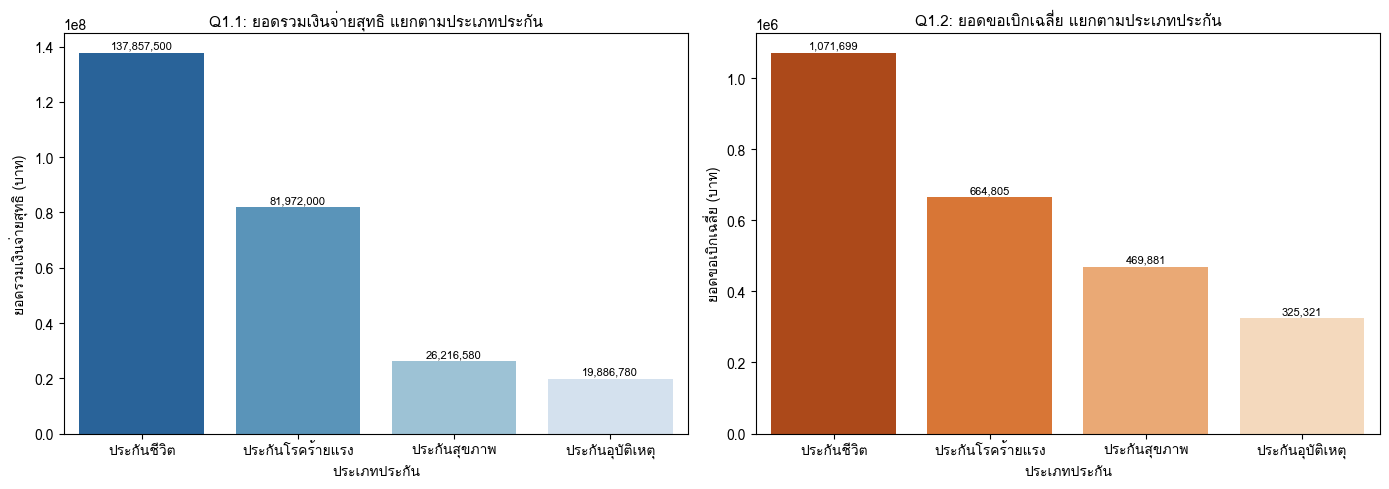

In [315]:
# กราฟข้อที่ 1
q1_df = pd.DataFrame({
    'insurance_type': ['ประกันชีวิต', 'ประกันโรคร้ายแรง', 'ประกันสุขภาพ', 'ประกันอุบัติเหตุ'],
    'total_net_payout': [137857500.00, 81972000.00, 26216579.78, 19886779.63],
    'avg_claim_amount': [1071699.13, 664804.59, 469881.22, 325320.82]
}).set_index('insurance_type')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar ยอดรวม (ซ้าย)
ax1 = sns.barplot(x=q1_df.index, y=q1_df['total_net_payout'], hue=q1_df.index, palette='Blues_r', ax=axes[0], legend=False)
axes[0].set_title('Q1.1: ยอดรวมเงินจ่ายสุทธิ แยกตามประเภทประกัน', fontsize=11, fontweight='bold')
axes[0].set_xlabel('ประเภทประกัน')
axes[0].set_ylabel('ยอดรวมเงินจ่ายสุทธิ (บาท)')
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=8)

# Bar ค่าเฉลี่ย (ขวา)
ax2 = sns.barplot(x=q1_df.index, y=q1_df['avg_claim_amount'], hue=q1_df.index, palette='Oranges_r', ax=axes[1], legend=False)
axes[1].set_title('Q1.2: ยอดขอเบิกเฉลี่ย แยกตามประเภทประกัน', fontsize=11, fontweight='bold')
axes[1].set_xlabel('ประเภทประกัน')
axes[1].set_ylabel('ยอดขอเบิกเฉลี่ย (บาท)')
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

ประกันชีวิตมีจำนวนเงินจ่ายสุทธิรวมสูงที่สุด รองลงมาคือประกันโจรกรรม ประกันสุขภาพ และประกันอุบัติเหตุ ตามลำดับ ขณะเดียวกันเมื่อดูยอดขอเบิกเฉลี่ย ประกันชีวิตก็มีค่าเฉลี่ยสูงที่สุด ส่วนประกันอุบัติเหตุมีค่าเฉลี่ยต่ำที่สุด

# คำถามที่ 2: ภาพรวมสถานะการอนุมัติ (Approved vs Rejected) มีจำนวนกี่เคส และจ่ายเงินสุทธิรวมเท่าใด?


In [316]:
# คำถามที่ 2: วิเคราะห์โดย pandas
q2_df = (df_claims.groupby("approval_status").agg(
         total_request = ("claim_id", "count"),
         total_payout = ("net_payout", "sum"),).sort_values(by="total_request", ascending=False))

display(q2_df)

,total_request,total_payout
approval_status,,
Approved,276,"265,932,859.41"
Rejected,24,0.00


In [317]:
# คำถามที่ 2: วิเคราะห์โดย SQL

q2_sql = """
SELECT
    approval_status,
    COUNT(claim_id) AS total_request,
    SUM(net_payout) AS total_payout
FROM claims_system
GROUP BY approval_status
ORDER BY total_request DESC;
"""

q2_result = pd.read_sql_query(q2_sql, conn)

display(q2_result)

,approval_status,total_request,total_payout
0,Approved,276,"265,932,859.41"
1,Rejected,24,0.00


In [318]:
# ข้อมูล Q2 (Approved vs Rejected) สำหรับกราฟข้อ 2
status_df = pd.DataFrame({
    'claim_status': ['Approved', 'Rejected'],
    'case_count': [276, 24],
    'net_paid_millions': [265.93, 0.00]
})

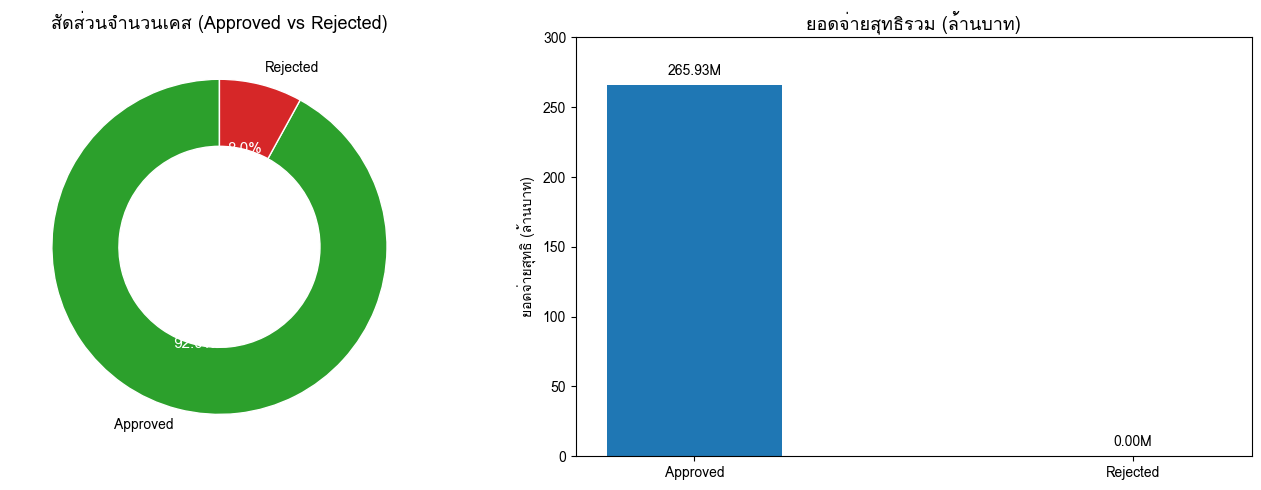

In [319]:
#กราฟข้อที่ 2
#ภาพรวมสถานะการอนุมัติ (Approved vs Rejected) และ จำนวนกี่เคส
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# สัดส่วนจำนวนเคส
colors_donut = ['#2ca02c', '#d62728']

wedges, texts, autotexts = axes[0].pie(
    status_df['case_count'],
    labels=status_df['claim_status'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_donut,
    wedgeprops=dict(width=0.4, edgecolor='w')
)
axes[0].set_title("สัดส่วนจำนวนเคส (Approved vs Rejected)", fontsize=13, fontweight='bold')

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_color('white')
    autotext.set_weight('bold')

# ยอดจ่ายสุทธิรวม
colors_bar = ['#1f77b4', '#ff7f0e']

bars = axes[1].bar(
    status_df['claim_status'],
    status_df['net_paid_millions'],
    color=colors_bar,
    width=0.4
)
axes[1].set_title("ยอดจ่ายสุทธิรวม (ล้านบาท)", fontsize=13, fontweight='bold')
axes[1].set_ylabel("ยอดจ่ายสุทธิ (ล้านบาท)")
axes[1].set_ylim(0, 300)

for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 5,
        f'{height:.2f}M',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()



จากข้อมูลทั้งหมดมี 300 เคส โดย Approved 276 เคส (92%) และ Rejected 24 เคส (8%) และยอดจ่ายสุทธิรวมเกิดขึ้นจากเคสที่ได้รับอนุมัติเป็นหลัก โดย Approved มียอดจ่ายสุทธิรวมประมาณ 265.93 ล้านบาท ส่วน Rejected ไม่มียอดจ่ายสุทธิ

# คำถามที่ 3: เมื่อจำแนกตามประเภทประกัน มีจำนวนเคสที่ผ่านอนุมัติและถูกปฏิเสธอย่างไรบ้าง?


In [320]:
# คำถามที่ 3: วิเคราะห์โดย pandas

# part1 จำนวนเคสที่ผ่านอนุมัติและถูกปฏิเสธ
q3_df = (df_claims.groupby(["insurance_type", "payment_status"]).agg(
         total_cases = ("claim_id", "count"),
         total_payout = ("net_payout", "sum"),).sort_values(by=["insurance_type", "payment_status"], ascending=False))
print("=== จำนวนเคสและยอดจ่ายรวม ( Completed = ผ่าน | Cancelled = ไม่ผ่าน ) ===")
display(q3_df)

# part2 เหตุผลที่ไม่ผ่าน พร้อมส่วนต่างเงินที่ยื่นเกินวงเงิน
df_rejected = df_claims[df_claims["payment_status"] == "Cancelled"].copy()
df_rejected["excess_amount"] = (df_rejected["claim_amount"] - df_rejected["coverage_limit"])

q3_detail_df = (df_rejected.groupby(["insurance_type", "claim_detail"]).agg(
                rejected_cases = ("claim_id", "count"),
                avg_claim_amount = ("claim_amount", "mean"),
                avg_coverage_limit = ("coverage_limit", "mean"),
                avg_axcess_amount = ("excess_amount", "mean"),).sort_values(by="rejected_cases", ascending=False))

print("\n=== เหตุผลที่ไม่ผ่าน และยอดเงินที่ยื่นเกินวงเงิน ==="
)
display(q3_detail_df)

=== จำนวนเคสและยอดจ่ายรวม ( Completed = ผ่าน | Cancelled = ไม่ผ่าน ) ===


total_cases   total_payout
insurance_type   payment_status                            
ประกันโรคร้ายแรง Paid                     70  81,972,000.00
ประกันอุบัติเหตุ Paid                     68  19,886,779.63
                 Cancelled                 7           0.00
ประกันสุขภาพ     Paid                     63  26,216,579.78
                 Cancelled                17           0.00
ประกันชีวิต      Paid                     75 137,857,500.00


=== เหตุผลที่ไม่ผ่าน และยอดเงินที่ยื่นเกินวงเงิน ===


rejected_cases  \
insurance_type   claim_detail                                                    
ประกันสุขภาพ     ผ่าตัดไส้ติ่งอักเสบฉุกเฉิน                                  6   
                 เข้ารับการรักษาผู้ป่วยใน (IPD) โรคไข้หวัดใหญ่               6   
                 เข้ารับการรักษาผู้ป่วยนอก (OPD) ลำไส้อักเสบ                 5   
ประกันอุบัติเหตุ เข้ารักษาฉุกเฉินจากลื่นล้มหกล้ม                             4   
                 กระดูกข้อเท้าแตกหักจากการเล่นกีฬา                           3   

                                                                avg_claim_amount  \
insurance_type   claim_detail                                                      
ประกันสุขภาพ     ผ่าตัดไส้ติ่งอักเสบฉุกเฉิน                           689,911.16   
                 เข้ารับการรักษาผู้ป่วยใน (IPD) โรคไข้หวัดใหญ่        712,611.01   
                 เข้ารับการรักษาผู้ป่วยนอก (OPD) ลำไส้อักเสบ          538,794.15   
ประกันอุบัติเหตุ เข้ารักษาฉุกเฉินจากลื่นล้มหกล้ม                      537,886.95   
                 กระดูกข้อเท้าแตกหักจากการเล่นกีฬา                    719,952.44   

                                                                avg_coverage_limit  \
insurance_type   claim_detail                                                        
ประกันสุขภาพ     ผ่าตัดไส้ติ่งอักเสบฉุกเฉิน                             675,000.00   
                 เข้ารับการรักษาผู้ป่วยใน (IPD) โรคไข้หวัดใหญ่          650,000.00   
                 เข้ารับการรักษาผู้ป่วยนอก (OPD) ลำไส้อักเสบ            500,000.00   
ประกันอุบัติเหตุ เข้ารักษาฉุกเฉินจากลื่นล้มหกล้ม                        512,500.00   
                 กระดูกข้อเท้าแตกหักจากการเล่นกีฬา                      683,333.33   

                                                                avg_axcess_amount  
insurance_type   claim_detail                                                      
ประกันสุขภาพ     ผ่าตัดไส้ติ่งอักเสบฉุกเฉิน                             14,911.16  
                 เข้ารับการรักษาผู้ป่วยใน (IPD) โรคไข้หวัดใหญ่          62,611.01  
                 เข้ารับการรักษาผู้ป่วยนอก (OPD) ลำไส้อักเสบ            38,794.15  
ประกันอุบัติเหตุ เข้ารักษาฉุกเฉินจากลื่นล้มหกล้ม                        25,386.96  
                 กระดูกข้อเท้าแตกหักจากการเล่นกีฬา                      36,619.11

In [321]:
# คำถามที่ 3 วิเคราะห์โดย SQL
# Part 1: จำนวนเคสที่ผ่านอนุมัติและถูกปฏิเสธ พร้อมยอดจ่ายรวม

q3_part1_sql = """
SELECT
    insurance_type,
    payment_status,
    COUNT(claim_id) AS total_cases,
    SUM(net_payout) AS total_payout
FROM claims_system
GROUP BY
    insurance_type,
    payment_status
ORDER BY
    insurance_type DESC,
    payment_status DESC;
"""

q3_part1_result = pd.read_sql_query(q3_part1_sql, conn)

display(q3_part1_result)


# Part 2: เหตุผลที่ไม่ผ่าน และยอดเงินที่ยื่นเกินวงเงิน

q3_part2_sql = """
SELECT
    insurance_type,
    claim_detail,
    COUNT(claim_id) AS rejected_cases,
    AVG(claim_amount) AS avg_claim_amount,
    AVG(coverage_limit) AS avg_coverage_limit,
    AVG(claim_amount - coverage_limit) AS avg_axcess_amount
FROM claims_system
WHERE payment_status = 'Cancelled'
GROUP BY
    insurance_type,
    claim_detail
ORDER BY
    rejected_cases DESC;
"""

q3_part2_result = pd.read_sql_query(q3_part2_sql, conn)

display(q3_part2_result)

,insurance_type,payment_status,total_cases,total_payout
0,ประกันโรคร้ายแรง,Paid,70,"81,972,000.00"
1,ประกันอุบัติเหตุ,Paid,68,"19,886,779.63"
2,ประกันอุบัติเหตุ,Cancelled,7,0.00
3,ประกันสุขภาพ,Paid,63,"26,216,579.78"
4,ประกันสุขภาพ,Cancelled,17,0.00
5,ประกันชีวิต,Paid,75,"137,857,500.00"


,insurance_type,claim_detail,rejected_cases,avg_claim_amount,avg_coverage_limit,avg_axcess_amount
0,ประกันสุขภาพ,ผ่าตัดไส้ติ่งอักเสบฉุกเฉิน,6,"689,911.16","675,000.00","14,911.16"
1,ประกันสุขภาพ,เข้ารับการรักษาผู้ป่วยใน (IPD) โรคไข้หวัดใหญ่,6,"712,611.01","650,000.00","62,611.01"
2,ประกันสุขภาพ,เข้ารับการรักษาผู้ป่วยนอก (OPD) ลำไส้อักเสบ,5,"538,794.15","500,000.00","38,794.15"
3,ประกันอุบัติเหตุ,เข้ารักษาฉุกเฉินจากลื่นล้มหกล้ม,4,"537,886.95","512,500.00","25,386.96"
4,ประกันอุบัติเหตุ,กระดูกข้อเท้าแตกหักจากการเล่นกีฬา,3,"719,952.44","683,333.33","36,619.11"


<Figure size 900x500 with 0 Axes>

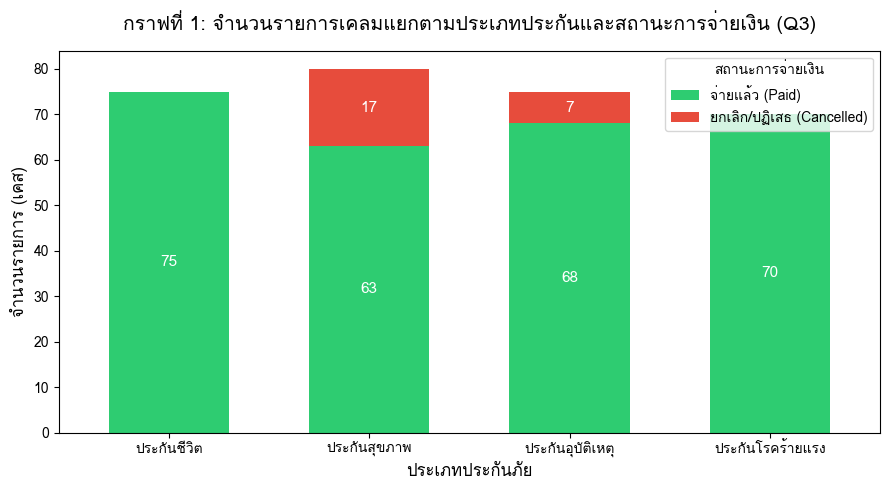

สรุปผลกราฟที่ 1: ประเภทประกันที่มีการอนุมัติจ่ายเงิน (Paid) มากที่สุดคือ ประกันชีวิต จำนวน 75 รายการ


In [322]:
# กราฟที่ 1: Stacked Bar Chart - จำนวน Paid / Cancelled แยกตามประเภทประกัน (กราฟหลัก Q3)
plt.figure(figsize=(9, 5))
status_counts = (
    df_claims.groupby(['insurance_type', 'payment_status'])
    .size()
    .unstack(fill_value=0)
)
cols = [c for c in ['Paid', 'Cancelled'] if c in status_counts.columns]
status_counts = status_counts[cols]

ax1 = status_counts.plot(
    kind='bar',
    stacked=True,
    color=['#2ecc71', '#e74c3c'],
    figsize=(9, 5),
    width=0.6,
)
plt.title(
    'กราฟที่ 1: จำนวนรายการเคลมแยกตามประเภทประกันและสถานะการจ่ายเงิน (Q3)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('ประเภทประกันภัย', fontsize=12)
plt.ylabel('จำนวนรายการ (เคส)', fontsize=12)
plt.legend(
    title='สถานะการจ่ายเงิน',
    labels=['จ่ายแล้ว (Paid)', 'ยกเลิก/ปฏิเสธ (Cancelled)'],
    frameon=True,
)
plt.xticks(rotation=0)

# แสดงตัวเลขบนแท่งกราฟ
for c in ax1.containers:
  for p in c:
    height = p.get_height()
    if height > 0:
      ax1.annotate(
          f'{int(height)}',
          (p.get_x() + p.get_width() / 2., p.get_y() + height / 2.),
          ha='center',
          va='center',
          color='white',
          fontweight='bold',
          fontsize=11,
      )

plt.tight_layout()
plt.show()

# สรุปผลข้อที่ 1
top_paid_type = status_counts['Paid'].idxmax()
top_paid_val = status_counts['Paid'].max()
print(
    f'สรุปผลกราฟที่ 1: ประเภทประกันที่มีการอนุมัติจ่ายเงิน (Paid) มากที่สุดคือ {top_paid_type} จำนวน {top_paid_val} รายการ'
)

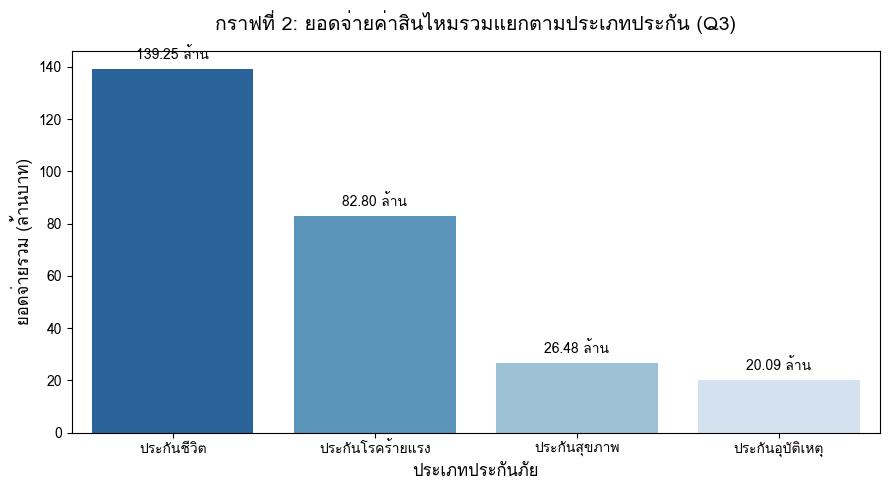

สรุปผลกราฟที่ 2: ประกันภัยที่มียอดจ่ายค่าสินไหมสูงสุดคือ ประกันชีวิต ด้วยยอดจ่ายรวม 139,250,000.00 บาท (139.25 ล้านบาท)


In [323]:
# กราฟที่ 2: Bar Chart - ยอดจ่ายจริงรวม (Paid Amount) แยกตามประเภทประกัน
plt.figure(figsize=(9, 5))
payout_summary = (
    df_claims.groupby('insurance_type')['paid_amount'].sum().reset_index()
)
payout_summary['paid_amount_m'] = payout_summary['paid_amount'] / 1e6
payout_summary = payout_summary.sort_values(
    by='paid_amount_m', ascending=False
)

ax2 = sns.barplot(
    data=payout_summary,
    x='insurance_type',
    y='paid_amount_m',
    hue='insurance_type',
    palette='Blues_r',
    legend=False,
)
plt.title(
    'กราฟที่ 2: ยอดจ่ายค่าสินไหมรวมแยกตามประเภทประกัน (Q3)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('ประเภทประกันภัย', fontsize=12)
plt.ylabel('ยอดจ่ายรวม (ล้านบาท)', fontsize=12)

# แสดงตัวเลขยอดเงินบนแท่งกราฟ
for p in ax2.patches:
  val = p.get_height()
  ax2.annotate(
      f'{val:,.2f} ล้าน',
      (p.get_x() + p.get_width() / 2., val),
      ha='center',
      va='bottom',
      fontsize=10,
      fontweight='bold',
      xytext=(0, 5),
      textcoords='offset points',
  )

plt.tight_layout()
plt.show()

# สรุปผลข้อที่ 2 (ดึงค่าแบบ iloc[0] ตามโครงสร้าง)
print(
    f"สรุปผลกราฟที่ 2: ประกันภัยที่มียอดจ่ายค่าสินไหมสูงสุดคือ {payout_summary.iloc[0]['insurance_type']} ด้วยยอดจ่ายรวม {payout_summary.iloc[0]['paid_amount']:,.2f} บาท ({payout_summary.iloc[0]['paid_amount_m']:.2f} ล้านบาท)"
)


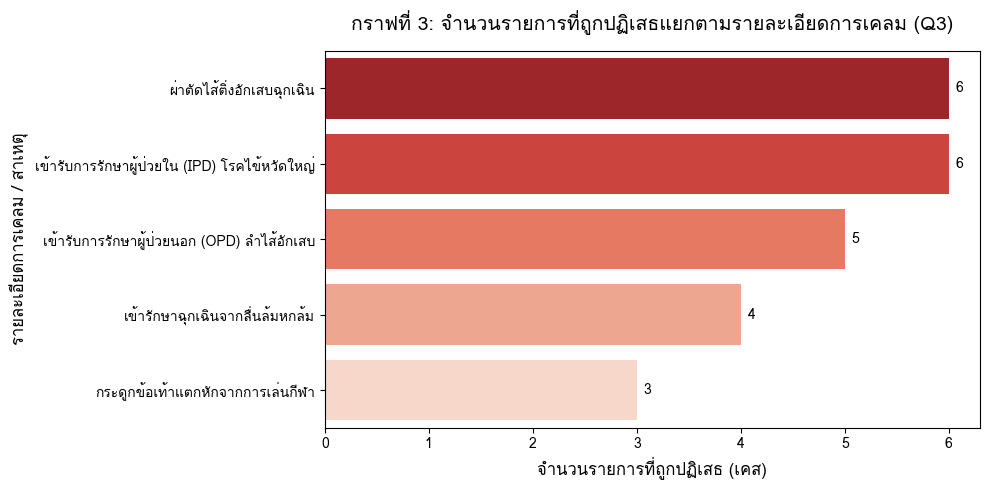

สรุปผลกราฟที่ 3: สาเหตุที่ถูกปฏิเสธการเคลมมากที่สุดคือ ผ่าตัดไส้ติ่งอักเสบฉุกเฉิน จำนวน 6 รายการ


In [324]:
rejected_df = df_claims[df_claims['payment_status'] == 'Cancelled'].copy()

detail_counts = rejected_df['claim_detail'].value_counts().reset_index()
detail_counts.columns = ['claim_detail', 'count']

plt.figure(figsize=(10, 5))
ax3 = sns.barplot(
    data=detail_counts,
    y='claim_detail',
    x='count',
    hue='claim_detail',
    palette='Reds_r',
    legend=False,
)
plt.title(
    'กราฟที่ 3: จำนวนรายการที่ถูกปฏิเสธแยกตามรายละเอียดการเคลม (Q3)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('จำนวนรายการที่ถูกปฏิเสธ (เคส)', fontsize=12)
plt.ylabel('รายละเอียดการเคลม / สาเหตุ', fontsize=12)

# แสดงตัวเลขจำนวนเคสตรงปลายแท่งกราฟ
for p in ax3.patches:
  val = p.get_width()
  ax3.annotate(
      f'{int(val)}',
      (val, p.get_y() + p.get_height() / 2.),
      ha='left',
      va='center',
      fontsize=10,
      fontweight='bold',
      xytext=(5, 0),
      textcoords='offset points',
  )

plt.tight_layout()
plt.show()

# สรุปผลข้อที่ 3
print(
    f"สรุปผลกราฟที่ 3: สาเหตุที่ถูกปฏิเสธการเคลมมากที่สุดคือ {detail_counts.iloc[0]['claim_detail']} จำนวน {detail_counts.iloc[0]['count']} รายการ"
)



เมื่อแยกตามประเภทประกัน จะเห็นว่าแต่ละประเภทมีทั้งเคสที่ Paid และ Cancelled แต่จำนวน Paid มากกว่า Cancelled โดยภาพรวม แสดงว่าการเคลมส่วนใหญ่สิ้นสุดด้วยการจ่ายเงิน ขณะที่บางส่วนถูกยกเลิก/ไม่ผ่าน

# คำถามที่ 4: ผู้รับประโยชน์กลุ่มไหน (บิดา, มารดา, บุตร ฯลฯ) มีจำนวนเคสมากสุด พร้อมยอดจ่ายสูงสุดและค่าเฉลี่ย?


In [325]:
# คำถามที่ 4: วิเคราะห์โดย pandas

q4_df = (df_claims.groupby("beneficiary_relationship").agg(
         total_cases = ("claim_id", "count"),
         max_net_payout = ("net_payout", "max"),
         avg_net_payout = ("net_payout", "mean"),).sort_values(by="total_cases", ascending=False))

display(q4_df)

,total_cases,max_net_payout,avg_net_payout
beneficiary_relationship,,,
บุตร,60,"2,722,500.00","866,835.03"
พี่น้อง,51,"2,920,500.00","967,573.84"
สามี,51,"2,871,000.00","719,399.80"
ภรรยา,51,"2,970,000.00","977,530.77"
บิดา,45,"2,920,500.00","948,092.90"
มารดา,42,"2,920,500.00","842,115.52"


In [326]:
# คำถามที่ 4: วิเคราะห์โดย SQL
q4_sql = """
SELECT
    beneficiary_relationship,
    COUNT(claim_id) AS total_cases,
    MAX(net_payout) AS max_net_payout,
    AVG(net_payout) AS avg_net_payout
FROM claims_system
GROUP BY beneficiary_relationship
ORDER BY total_cases DESC;
"""

q4_result = pd.read_sql_query(q4_sql, conn)

display(q4_result)

,beneficiary_relationship,total_cases,max_net_payout,avg_net_payout
0,บุตร,60,"2,722,500.00","866,835.03"
1,สามี,51,"2,871,000.00","719,399.80"
2,ภรรยา,51,"2,970,000.00","977,530.77"
3,พี่น้อง,51,"2,920,500.00","967,573.84"
4,บิดา,45,"2,920,500.00","948,092.90"
5,มารดา,42,"2,920,500.00","842,115.52"


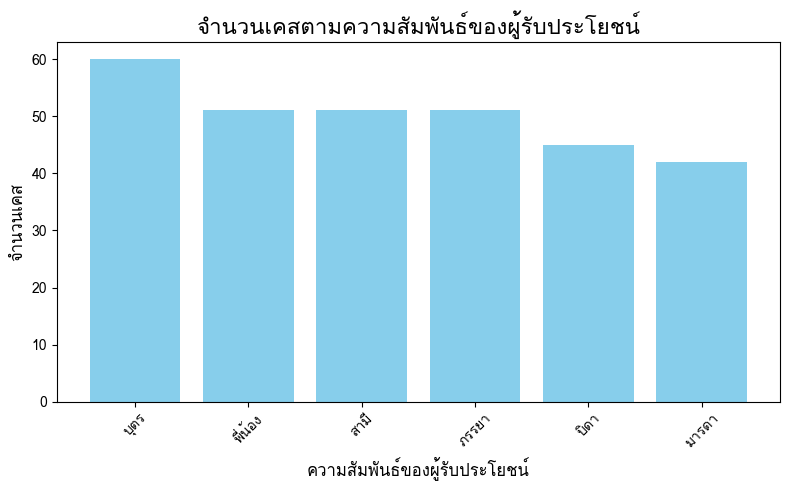

In [327]:
# กราฟแท่งที่ 1 : จำนวนเคสตามความสัมพันธ์ของผู้รับประโยชน์

q4_cases = (
    df_claims.groupby("beneficiary_relationship")
    .agg(total_cases=("claim_id", "count"))
    .sort_values(by="total_cases", ascending=False)
)

plt.figure(figsize=(8, 5))
plt.bar(q4_cases.index, q4_cases["total_cases"], color="skyblue")

plt.title("จำนวนเคสตามความสัมพันธ์ของผู้รับประโยชน์", fontsize=16)
plt.xlabel("ความสัมพันธ์ของผู้รับประโยชน์", fontsize=12)
plt.ylabel("จำนวนเคส", fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!


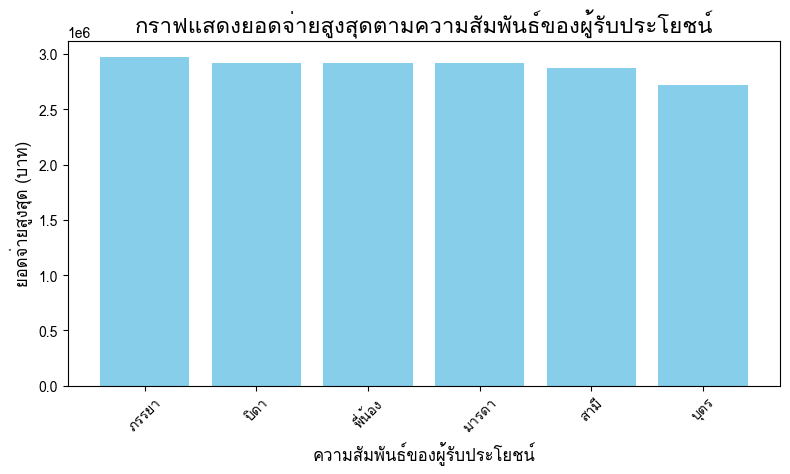

In [331]:
data = {
    'ความสัมพันธ์ของผู้รับประโยชน์': ['ภรรยา', 'บิดา', 'พี่น้อง', 'มารดา', 'สามี', 'บุตร'],
    'ยอดจ่ายสูงสุด': [2970000, 2920500	, 2920500, 2920500	, 2871000	, 2722500	]
}

df_thai = pd.DataFrame(data)

plt.figure(figsize=(8, 5))
plt.bar(
    df_thai['ความสัมพันธ์ของผู้รับประโยชน์'],
    df_thai['ยอดจ่ายสูงสุด'],
    color='skyblue'
)

plt.title('กราฟแสดงยอดจ่ายสูงสุดตามความสัมพันธ์ของผู้รับประโยชน์', fontsize=16)
plt.xlabel('ความสัมพันธ์ของผู้รับประโยชน์', fontsize=12)
plt.ylabel('ยอดจ่ายสูงสุด (บาท)', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

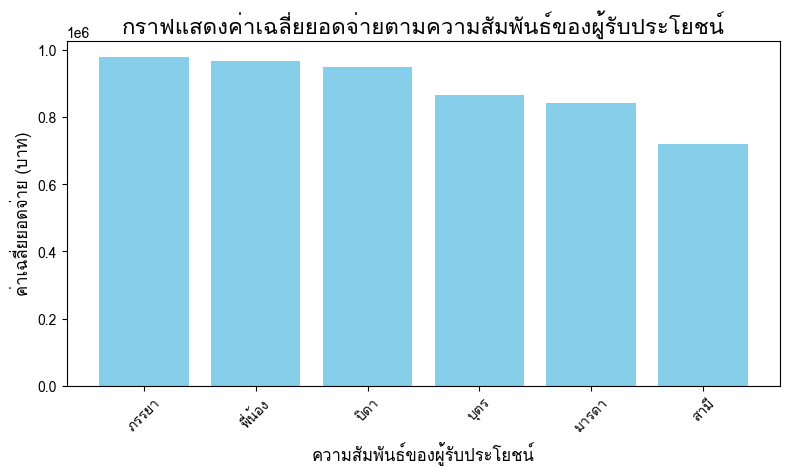

In [333]:
data = {
    'ความสัมพันธ์ของผู้รับประโยชน์': ['ภรรยา', 'พี่น้อง', 'บิดา', 'บุตร', 'มารดา', 'สามี'],
    'ค่าเฉลี่ยยอดจ่าย': [977530.77, 967573.84, 948092.90, 866835.03, 842115.52, 719399.80]
}

df_thai = pd.DataFrame(data)

plt.figure(figsize=(8, 5))
plt.bar(
    df_thai['ความสัมพันธ์ของผู้รับประโยชน์'],
    df_thai['ค่าเฉลี่ยยอดจ่าย'],
    color='skyblue'
)

plt.title('กราฟแสดงค่าเฉลี่ยยอดจ่ายตามความสัมพันธ์ของผู้รับประโยชน์', fontsize=16)
plt.xlabel('ความสัมพันธ์ของผู้รับประโยชน์', fontsize=12)
plt.ylabel('ค่าเฉลี่ยยอดจ่าย (บาท)', fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

เมื่อจำแนกตามความสัมพันธ์ของผู้รับประโยชน์ พบว่าบุตรเป็นกลุ่มที่มีจำนวนเคสมากที่สุด (60 เคส) ขณะที่ ภรรยามีเคสที่มียอดจ่ายสูงสุดประมาณ 2.7 ล้านบาท และเมื่อดูยอดจ่ายเฉลี่ย ภรรยามีค่าเฉลี่ยสูงที่สุดประมาณ 9.77 ล้านบาท

#สรุป

ข้อมูลสะท้อนว่า “จำนวนเคส” กับ “มูลค่าการจ่าย” ไม่ได้มีความสัมพันธ์กันโดยตรงเสมอไป เพราะบางกลุ่มมีจำนวนเคสมาก แต่ไม่ได้หมายความว่าจะมียอดจ่ายสูงที่สุด เช่น ผู้รับประโยชน์ที่เป็นบุตรมีจำนวนเคสมากที่สุด แต่ยอดจ่ายสูงสุดและยอดจ่ายเฉลี่ยสูงสุดอยู่ที่ภรรยา


ในด้านประเภทประกัน ประกันชีวิตโดดเด่นที่สุดทั้งในด้านยอดจ่ายรวมและยอดขอเบิกเฉลี่ย ขณะที่ภาพรวมสถานะการเคลมพบว่าส่วนใหญ่ได้รับอนุมัติและมีการจ่ายเงินจริง